# ShopFast - Customer Retention Analysis
**Junior Data Analyst Take-Home Assignment**  
**Submitted by:** Srimathy  
**Date:** April 10, 2026

## Project Overview
Analysis of declining repeat customer revenue at ShopFast. Focused on cleaning data, calculating key metrics (MAU, Revenue by Category, CLV), and identifying retention issues.

In [7]:
import pandas as pd
import numpy as np  

### Load raw files

In [8]:
customers = pd.read_csv('c:/Users/ssy/Documents/JDA/Data/customers.csv') 
orders = pd.read_csv('c:/Users/ssy/Documents/JDA/Data/orders.csv')
order_items = pd.read_csv('c:/Users/ssy/Documents/JDA/Data/order_items.csv')
reviews = pd.read_csv('c:/Users/ssy/Documents/JDA/Data/reviews.csv')

In [9]:
customers.head()

,customer_id,signup_date,region,acquisition_channel
0,C0001,11/23/2024,East,Social
1,C0002,2024-04-24,North,Email
2,C0003,2025-01-14,North,Email
3,C0004,08/04/2024,North,Social
4,C0005,2024-04-29,North,Email


In [10]:
orders.head()

,order_id,customer_id,order_date,order_status,total_amount,shipped_date,delivered_date,shipping_time_days
0,10855,C0080,2025-01-13,Completed,184.96,2025-01-17,2025-01-20,7.0
1,10521,C0026,2024-08-10,Completed,284.64,2024-08-17,2024-08-22,12.0
2,11064,C0122,2025-04-24,Completed,242.62,2025-04-25,2025-04-30,6.0
3,10976,C0103,2025-03-10,Completed,245.11,2025-03-23,2025-04-01,22.0
4,10360,C0103,2024-05-31,Completed,296.52,2024-06-12,2024-06-19,19.0


In [11]:
order_items.head()

,order_id,product_id,category,price,shipping_cost,revenue
0,10002,P5831,Electronics,109.06,8.72,117.78
1,10003,P1173,Electronics,54.00,3.45,57.45
2,10003,P2659,Beauty,35.70,6.68,42.38
3,10003,P1425,Home,56.63,5.68,62.31
4,10003,P2769,Beauty,46.15,4.93,51.08


In [12]:
reviews.head()

,order_id,product_id,review_score,comment
0,10003,P1173,4.0,Love it
1,10005,P6861,4.0,As described
2,10007,P8657,4.0,NaN
3,10009,P6431,3.0,As described
4,10011,P3855,2.0,Late delivery


In [13]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   customer_id          180 non-null    object
 1   signup_date          180 non-null    object
 2   region               180 non-null    object
 3   acquisition_channel  180 non-null    object
dtypes: object(4)
memory usage: 5.8+ KB


In [14]:
orders.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            1197 non-null   int64  
 1   customer_id         1197 non-null   object 
 2   order_date          1197 non-null   object 
 3   order_status        1197 non-null   object 
 4   total_amount        1197 non-null   float64
 5   shipped_date        924 non-null    object 
 6   delivered_date      924 non-null    object 
 7   shipping_time_days  924 non-null    float64
dtypes: float64(2), int64(1), object(5)
memory usage: 74.9+ KB


In [15]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2278 entries, 0 to 2277
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       2278 non-null   int64  
 1   product_id     2278 non-null   object 
 2   category       2278 non-null   object 
 3   price          2278 non-null   float64
 4   shipping_cost  2278 non-null   float64
 5   revenue        2278 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 106.9+ KB


In [16]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   order_id      499 non-null    int64  
 1   product_id    499 non-null    object 
 2   review_score  445 non-null    float64
 3   comment       431 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 15.7+ KB


### =================== PART 1: CLEANING =====================

### 1. Removing duplicate orders

In [17]:
orders.duplicated().sum() # There are 8 duplicates values found in the orders dataset. 

np.int64(8)

In [18]:
orders[orders.duplicated()]  #These are duplicate values in found in the second occurence. We will remove them in the next step.

,order_id,customer_id,order_date,order_status,total_amount,shipped_date,delivered_date,shipping_time_days
358,10227,C0128,2024-04-05,Completed,51.56,2024-04-12,2024-04-21,16.0
575,10169,C0090,2024-03-08,Completed,141.95,2024-03-14,2024-03-18,10.0
644,11180,C0093,2025-06-23,Completed,267.30,2025-06-24,2025-07-04,11.0
683,10512,C0142,2024-08-03,Completed,266.43,2024-08-10,2024-08-19,16.0
713,10626,C0166,2024-09-27,Completed,175.72,2024-10-10,2024-10-15,18.0
724,10324,C0069,05/20/2024,Completed,307.99,2024-05-28,2024-06-07,18.0
1099,10643,C0131,2024-10-06,Completed,112.45,2024-10-17,2024-10-21,15.0
1146,11058,C0089,2025-04-20,Completed,180.37,2025-04-22,2025-04-30,10.0


In [19]:
# Before removing the duplicated rows
print("No. of Rows before removing duplicates:", len(orders))

No. of Rows before removing duplicates: 1197


In [20]:
orders = orders.drop_duplicates(
    subset=["order_id", "customer_id", "order_date", "order_status", "total_amount"], keep="first")

In [21]:
# After removing the duplicated rows
print("No. of Rows after removing duplicates:", len(orders))

No. of Rows after removing duplicates: 1189


In [22]:
orders.duplicated(subset=["order_id", "customer_id", "order_date", "order_status", "total_amount"]).sum()

np.int64(0)

### 2. Normalizing the Date Columns

In [23]:
#Normalising the date column in Customers dataset

customers['signup_date'] = pd.to_datetime(customers['signup_date'], errors='coerce',format='mixed')
customers.head()

,customer_id,signup_date,region,acquisition_channel
0,C0001,2024-11-23,East,Social
1,C0002,2024-04-24,North,Email
2,C0003,2025-01-14,North,Email
3,C0004,2024-08-04,North,Social
4,C0005,2024-04-29,North,Email


In [24]:
#Normalising the date colums in Orders data and the Empty values in date will become "NaT"

date_cols = ['order_date', 'shipped_date', 'delivered_date']

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col],
        errors="coerce", format='mixed')

### QA Check: 

In [25]:
# Check how many NaT values appeared after date conversion
for col in date_cols:
    NaT_countS = orders[col].isna().sum()
    print(f"{col}: {NaT_countS} NaT values")

order_date: 0 NaT values
shipped_date: 273 NaT values
delivered_date: 273 NaT values


### 3. Reviews - Handling Missing scores

In [26]:
print("No of Null Values:", reviews['review_score'].isna().sum())   # Before removing the null values.
print(len(reviews))

No of Null Values: 54
499


In [27]:
reviews = reviews.dropna(subset=['review_score'])  #Dropping the null values
reviews['comment'] = reviews['comment'].fillna('NaN')

In [28]:
print("After removing the Null Values:", reviews['review_score'].isna().sum()) 

After removing the Null Values: 0


### QA Check:

In [29]:
# Checking if there are any negative values in the total_amount column of the orders dataset.

print("total_amount all >=0?", (orders['total_amount'] >= 0).all())

total_amount all >=0? True


In [30]:
# Checking the number of uncompleted orders in the orders dataset.

print("No. of Un completed Orders:", len(orders[orders['order_status']!='Completed']))

No. of Un completed Orders: 273


In [31]:
# Checking the number of completed orders in the orders dataset.

print("Completed orders after cleaning:", len(orders[orders['order_status']=='Completed']))

Completed orders after cleaning: 916



### ============= PART 3: Visualization & Retention Narrative =============


In [41]:

import matplotlib.pyplot as plt
import seaborn as sns

# Create completed orders dataframe (Important!)
completed_orders = orders[orders['order_status'] == 'Completed'].copy()


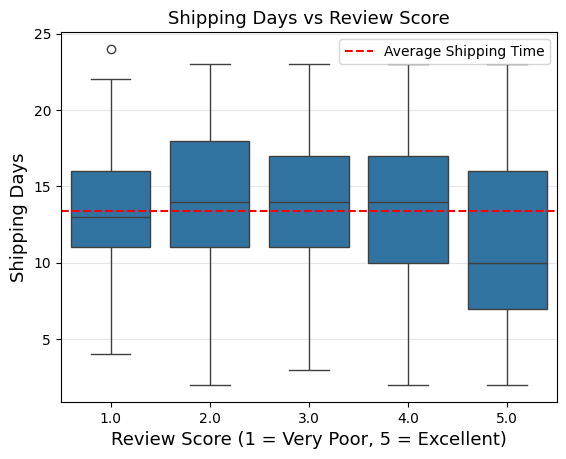

In [ ]:
merged = completed_orders.merge(reviews, on='order_id', how='inner')

# Filter valid data
merged = merged[
    (merged['shipping_time_days'].notna()) & 
    (merged['shipping_time_days'] >= 0) &      # Remove negative days if any
    (merged['review_score'].notna())
].copy()

sns.boxplot(x='review_score', 
            y='shipping_time_days', 
            data=merged[merged['shipping_time_days'] >= 0])

plt.title('Shipping Days vs Review Score', fontsize=13)
plt.xlabel('Review Score (1 = Very Poor, 5 = Excellent)', fontsize=13)
plt.ylabel('Shipping Days', fontsize=13)
plt.grid(axis='y', alpha=0.3)

plt.axhline(y=merged['shipping_time_days'].mean(), color='red', linestyle='--', 
            label='Average Shipping Time')
plt.legend()
plt.show()

- Customers who receive their orders faster tend to give much better reviews. Orders with 1-star and 2-star reviews took significantly longer to deliver on average. On the other hand, orders that received 4-star and 5-star reviews were delivered noticeably quicker. 

- This clearly shows that shipping speed has a strong impact on customer satisfaction. 
Long delivery times appear to be one of the main reasons customers are not returning to ShopFast. 


## Retention Analysis

### Monthly Active Users by Month

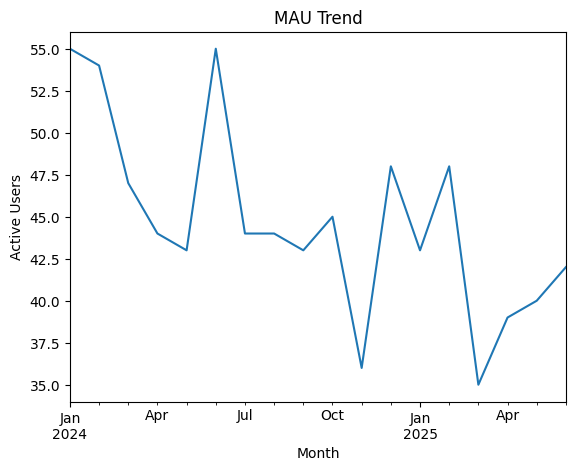

<Figure size 640x480 with 0 Axes>

In [54]:
ompleted_orders = orders[orders['order_status'] == 'Completed'].copy()

completed_orders['month'] = completed_orders['order_date'].dt.to_period('M')

mau = completed_orders.groupby('month')['customer_id'].nunique()


mau = mau.sort_index().tail(20)

mau.plot()
plt.title("MAU Trend")
plt.xlabel("Month")
plt.ylabel("Active Users")
plt.show()
plt.savefig("mau_chart.png", dpi=300)

Monthly Active Users have been declining over the last few months. There was a peak in mid-2024, but after January 2025, MAU dropped noticeably and reached its lowest point in recent months. Repeat Customer activity is weakening.

#### Recommedation:
The marketing team should implement targeted engagement strategies such as email campaigns, discounts, and push notifications during periods of declining MAU (notably when it drops to around 48 users). These campaigns should aim to re-engage inactive users and stabilize monthly activity levels.

#### Repeat vs One-time Customers

One-time customers: 5
Repeat customers: 175


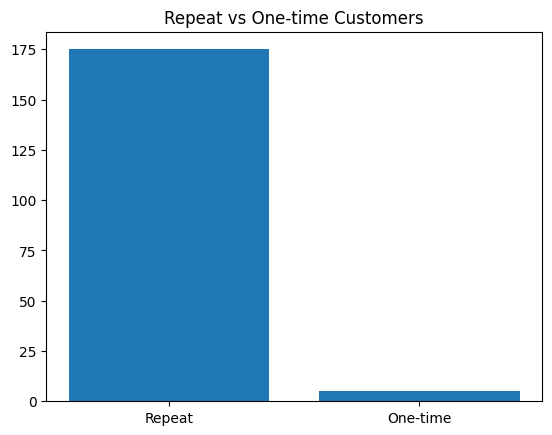

In [ ]:
# Filter only completed orders
completed_orders = orders[orders['order_status'] == 'Completed']

# Count orders per customer
customer_orders = completed_orders.groupby('customer_id').size()

# Count one-time and repeat customers  
one_time = (customer_orders == 1).sum()
repeat_customers = (customer_orders > 1).sum()

print("One-time customers:", one_time)
print("Repeat customers:", repeat_customers)

import matplotlib.pyplot as plt
plt.bar(['Repeat', 'One-time'], [repeat_customers, one_time])
plt.title("Repeat vs One-time Customers")
plt.show()

Almost all orders (over 99%) come from repeat customers. Very few new (one-time) customers are placing orders. This shows that ShopFast has a loyal customer base, but these existing customers are buying less frequently now.

In [36]:
merged = order_items.merge(orders, on='order_id')
merged['revenue'] = merged['price'] + merged['shipping_cost']

revenue_by_category = merged.groupby('category')['revenue'].sum().sort_values(ascending=False)

####  Revenue By Category

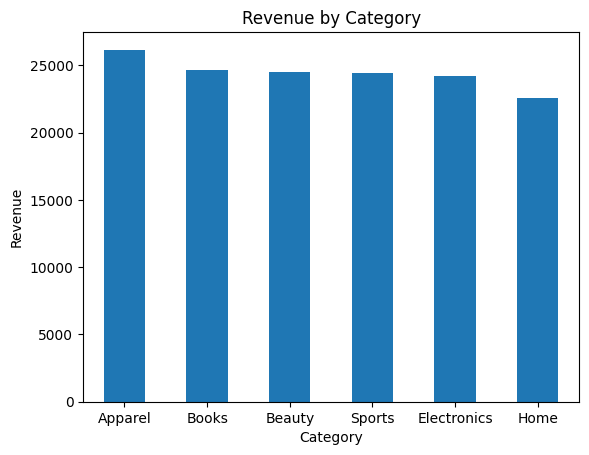

In [50]:
plt.figure()
revenue_by_category.plot(kind='bar')

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.xticks(rotation=0)
plt.show()

Revenue is focused in a few important product categories, most notably apparel and books, which account for the majority of overall sales. Lower-performing categories may require tailored measures to increase their contribution.

### Shipping Time 

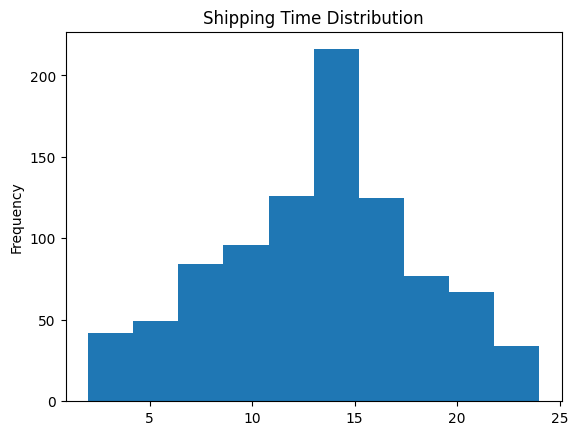

In [38]:
orders['shipping_time_days'].plot(kind='hist')
plt.title("Shipping Time Distribution")
plt.show()

Most orders are delivered within a 10 to 15 day range, showing usual delivery performance. However, some orders take longer time to arrive. This can affects the customer satisfaction.

#### CONCLUSION:

Even though it seems that most users are returning customers, we're seeing decreasing retention. Monthly Active users are decreasing and "slow delivery" is a clear pain point (customers who had slow deliveries gave considerably lower scores) especially if high revenue categories like Apparel and Books are impacted more severely.

### Recommendations
#### 1. Improve Shipping Speed (Highest Priority)
- Target reducing average delivery time to under 10 days, especially for Apparel and Books. Consider fast-shipping options or better logistics partners.
- Expected Impact: Higher review scores and improved repeat purchases.

#### 2. Launch Targeted Re-engagement Campaigns
- Run personalized “We Miss You” offers via Email and SMS to customers who haven’t ordered in 45+ days.
- Expected Impact: Reverse MAU decline.

#### 3. Category-Focused Loyalty Program
- Introduce special bundles, free shipping, and loyalty rewards focused on Apparel and Books (top revenue categories). Prioritize Email-acquired customers (highest CLV).
- Expected Impact: Increase repeat purchase frequency.
